## PySpark Session Setup

We are using historical weather and wheat futures data to predict future trading volumes of wheat futures

In [2]:
##Install Pyspark
! pip install pyspark >& /dev/null

##Import Required Libraries
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, isnan, when, count, to_date, length, substring, regexp_replace
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F


##Start Session
spark = SparkSession.builder.appName("wheat_futures_price_prediction").getOrCreate()

25/04/23 17:01:19 WARN Utils: Your hostname, codespaces-084d34 resolves to a loopback address: 127.0.0.1; using 10.0.0.116 instead (on interface eth0)
25/04/23 17:01:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/23 17:01:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Data Processing

In [3]:
###Read Weather and Priceing Datasets
weather_raw = spark.read.csv('weather_data_RAW.csv', header=True, inferSchema=True)
wheat_price_data = spark.read.csv('US_wheat_future_pricing_RAW.csv', header=True, inferSchema=True)

##Parse Date Column for consistant format
weather = weather_raw.withColumn(
    "Date",
    to_date(col("datetime"), "M/d/yyyy")      
).drop("datetime")                            

pricing = wheat_price_data.withColumn(
    "Date",
    to_date(col("Date"), "M/d/yyyy")        
)

##Merge on Date
merged = weather.join(pricing, on="Date", how="left")

##Clean Column Names
old_cols = merged.columns
new_cols = [c.replace('.', '').replace(' ', '_') for c in old_cols]
merged_clean = merged.toDF(*new_cols)

merged_clean.show(5)



25/04/23 17:01:34 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
25/04/23 17:01:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----+---------+--------+---------+-------+----------------+----------+----------+--------------+-----------+-------+----------+-------------------+-------------------+---------+--------------------+--------------------+-----------------+--------------------+------+------+------+------+------+--------+
|      Date| name|tempmax|tempmin|temp|feelslikemax|feelslikemin|feelslike| dew|humidity|precip|precipprob|precipcover|preciptype|snow|snowdepth|windgust|windspeed|winddir|sealevelpressure|cloudcover|visibility|solarradiation|solarenergy|uvindex|severerisk|            sunrise|             sunset|moonphase|          conditions|         description|             icon|            stations| Price|  Open|  High|   Low|   Vol|Change_%|
+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----

In [4]:

#print([name for name, dtype in merged_clean.dtypes if dtype == 'string'])

int_columns = ["Price", "Open", "High", "Low"]  # Replace with your actual column names
##Type Casting
for col_name in int_columns:
   merged_clean = merged_clean.withColumn(col_name, col(col_name).cast("int"))
merged_clean = merged_clean.withColumn(
    "Vol",
    when(
        col("Vol").rlike("K$"),  # Only process if ends with 'K'
        (regexp_replace(col("Vol"), "K", "").cast("float") * 1000).cast("string")
    ).otherwise(col("Vol"))  # If not ending in K, keep as is
)
merged_clean = merged_clean.withColumn(
    "Change_%",
    when(
        col("Change_%").rlike("%$"),  # Only process if ends with 'K'
        (regexp_replace(col("Change_%"), "%", "").cast("float")).cast("string")
    ).otherwise(col("Change_%"))  # If not ending in K, keep as is
)
float_columns = ["Vol", "Change_%"]
for col_name in float_columns:
    merged_clean = merged_clean.withColumn(col_name, col(col_name).cast("float"))

merged_clean = merged_clean.withColumnRenamed("Vol", "Volume").withColumnRenamed("Change_%", "Change")
merged_clean.printSchema()


root
 |-- Date: date (nullable = true)
 |-- name: integer (nullable = true)
 |-- tempmax: double (nullable = true)
 |-- tempmin: double (nullable = true)
 |-- temp: double (nullable = true)
 |-- feelslikemax: double (nullable = true)
 |-- feelslikemin: double (nullable = true)
 |-- feelslike: double (nullable = true)
 |-- dew: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- precip: double (nullable = true)
 |-- precipprob: integer (nullable = true)
 |-- precipcover: double (nullable = true)
 |-- preciptype: string (nullable = true)
 |-- snow: double (nullable = true)
 |-- snowdepth: double (nullable = true)
 |-- windgust: double (nullable = true)
 |-- windspeed: double (nullable = true)
 |-- winddir: double (nullable = true)
 |-- sealevelpressure: double (nullable = true)
 |-- cloudcover: double (nullable = true)
 |-- visibility: double (nullable = true)
 |-- solarradiation: double (nullable = true)
 |-- solarenergy: double (nullable = true)
 |-- uvindex: integer 


EDA

In [5]:
##Check for Nulls

for column in merged_clean.columns:
    null_count = merged_clean.filter(F.col(column).isNull()).count()
    if null_count > 0:
        print(f"The column '{column}' has {null_count} null values.")

##Exploratory Analysis on Numeric Columns
numeric_cols = [c for c, dtype in merged_clean.dtypes if dtype in ("float","integer", "double", "int")]
numeric_cols = [c for c in numeric_cols if c not in ["Date", "name"]]
merged_clean.describe(numeric_cols).show()



The column 'preciptype' has 7951 null values.
The column 'windgust' has 3 null values.
The column 'visibility' has 343 null values.
The column 'severerisk' has 9844 null values.
The column 'Price' has 4688 null values.
The column 'Open' has 4688 null values.
The column 'High' has 4700 null values.
The column 'Low' has 4672 null values.
The column 'Volume' has 4552 null values.
The column 'Change' has 4376 null values.


+-------+------------------+----------------+-----------------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+
|summary|           tempmax|         tempmin|             temp|      feelslikemax|      feelslikemin|         feelslike|               dew|         humidity|             precip|        precipprob|       precipcover|               snow|         snowdepth|          windgust|        windspeed|           winddir|  sealevelpressure|        cloudcover|        visibility|    solarradiation|      solarenergy|           uvindex|

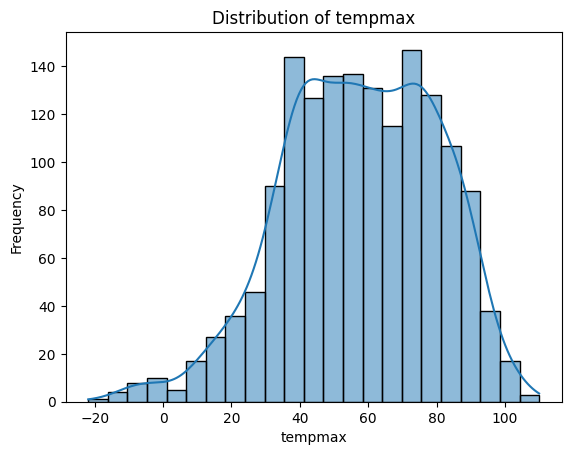

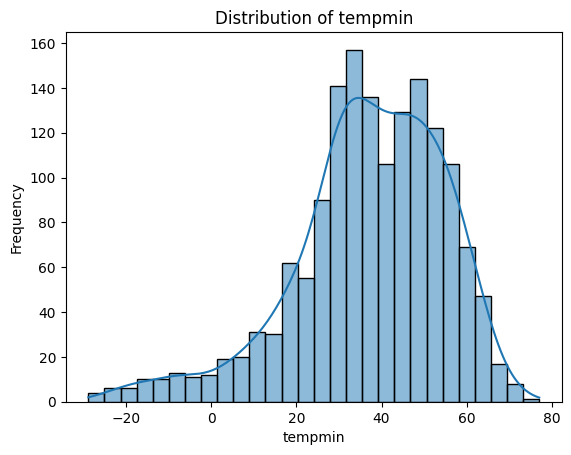

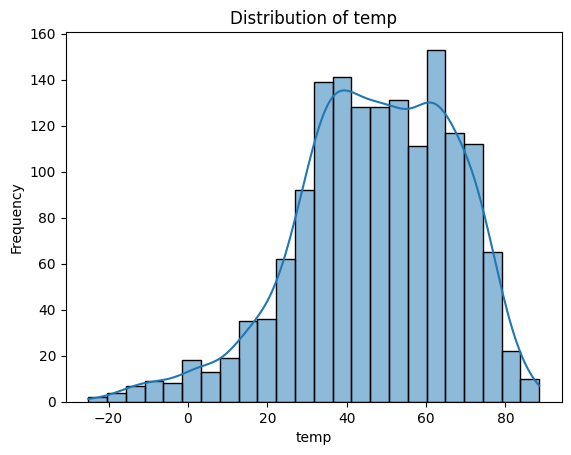

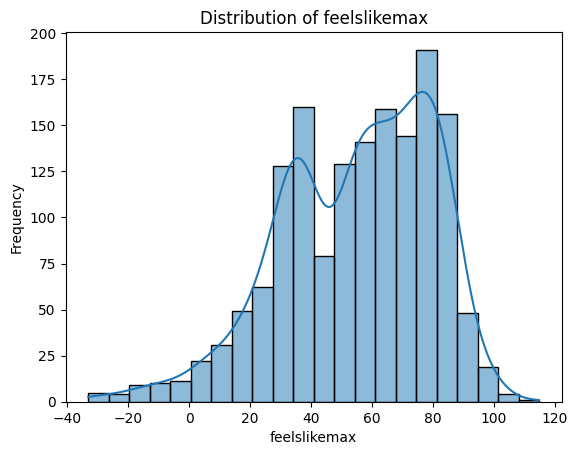

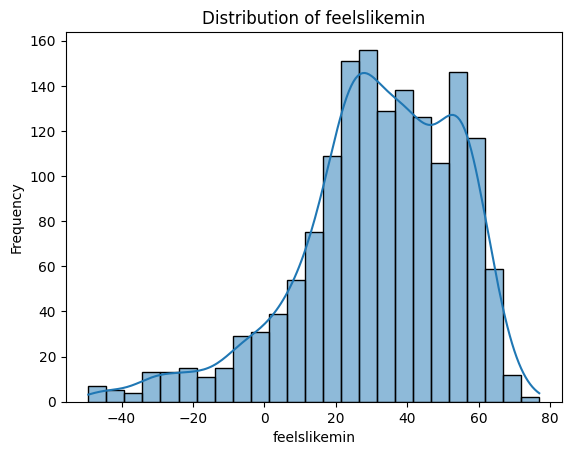

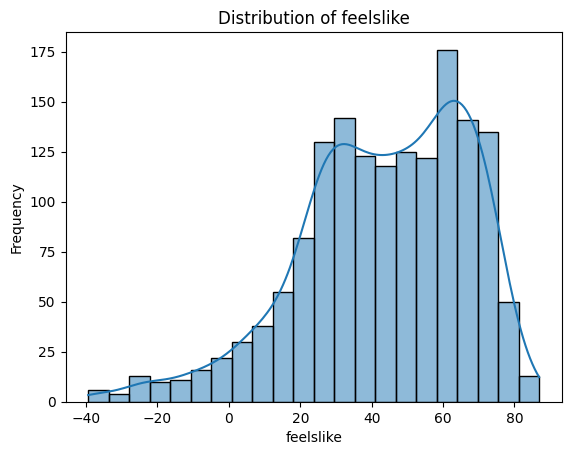

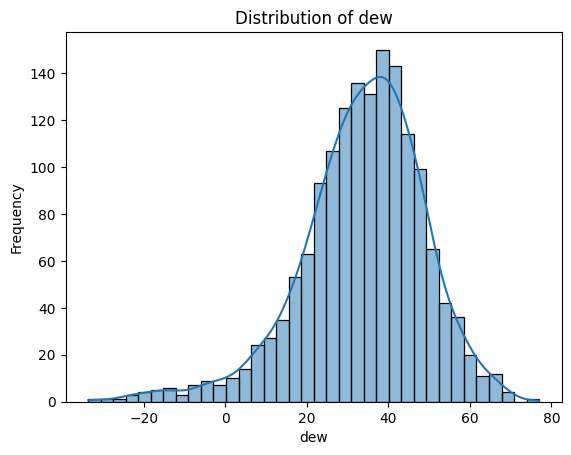

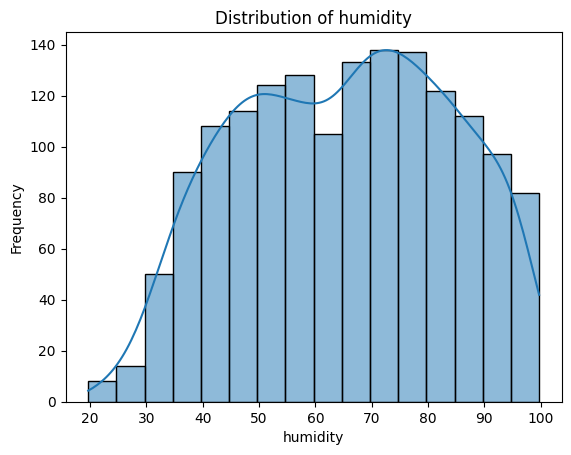

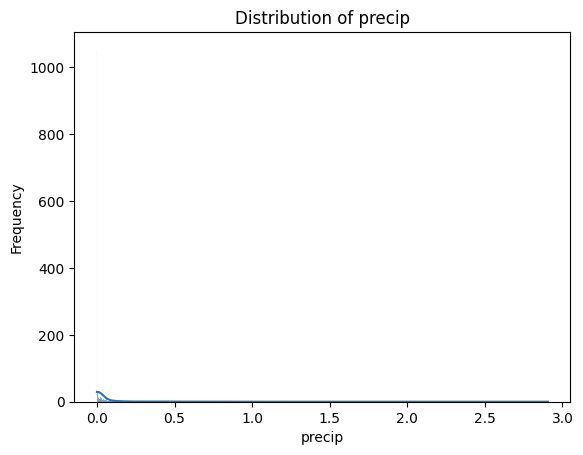

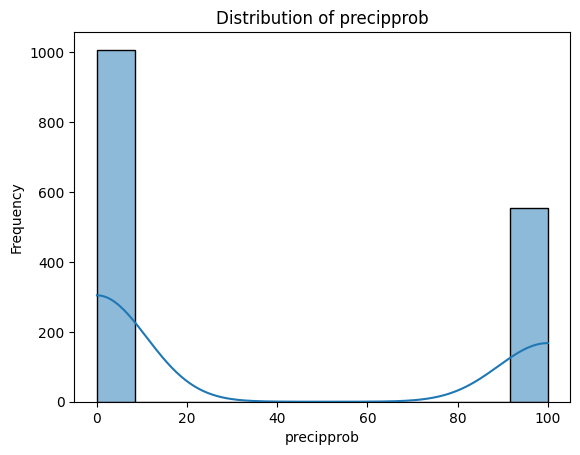

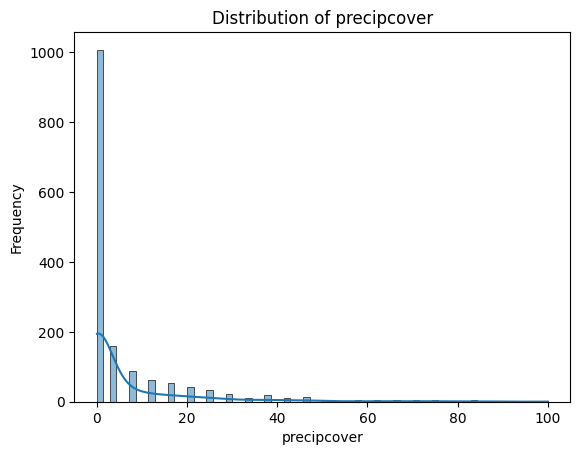

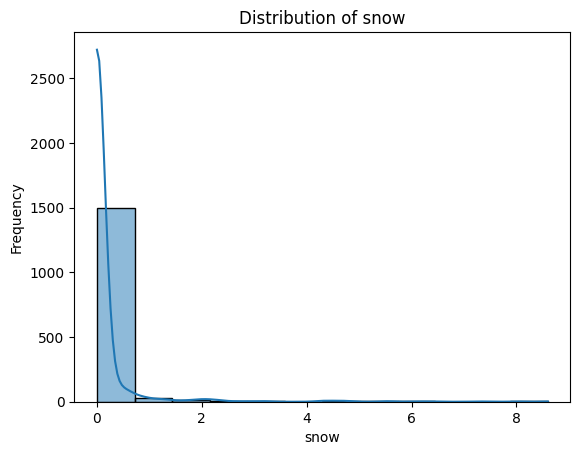

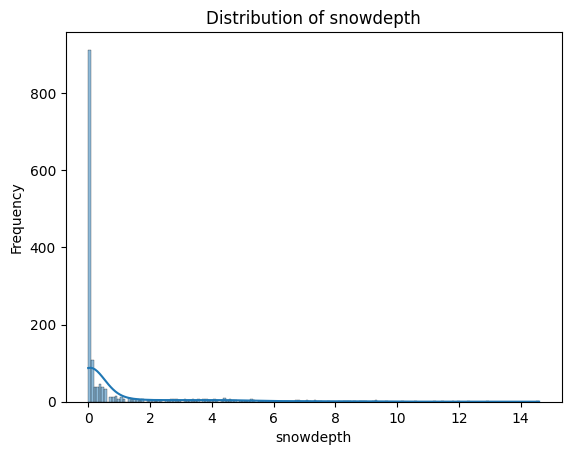

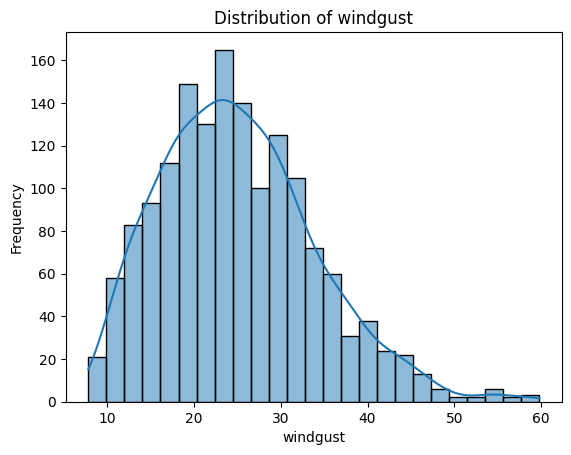

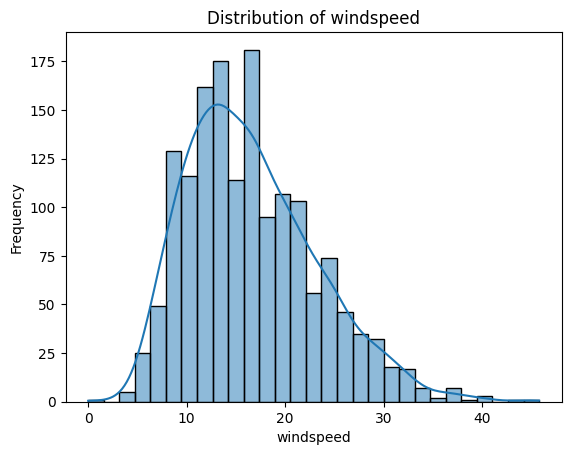

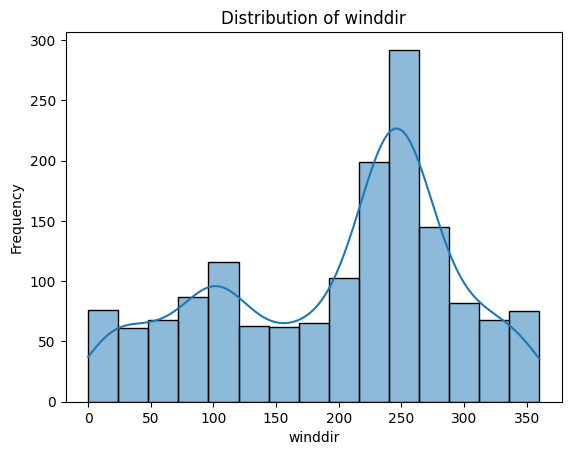

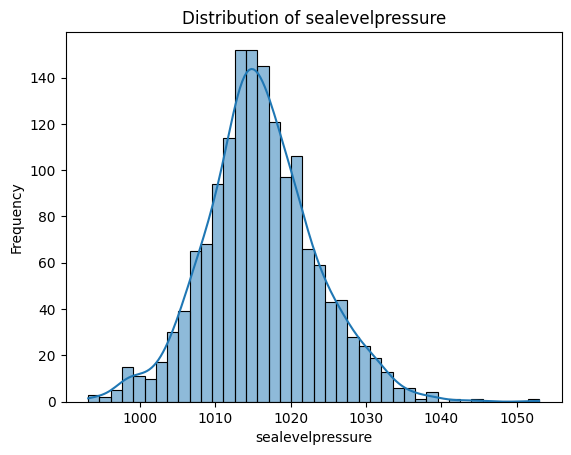

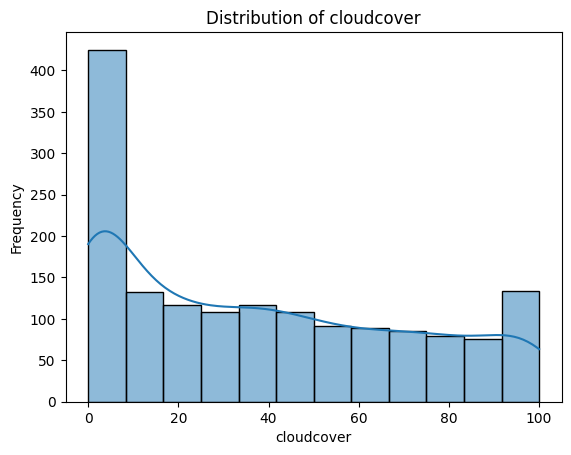

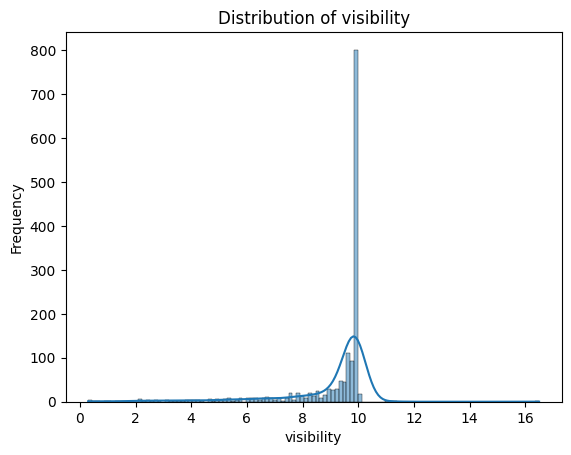

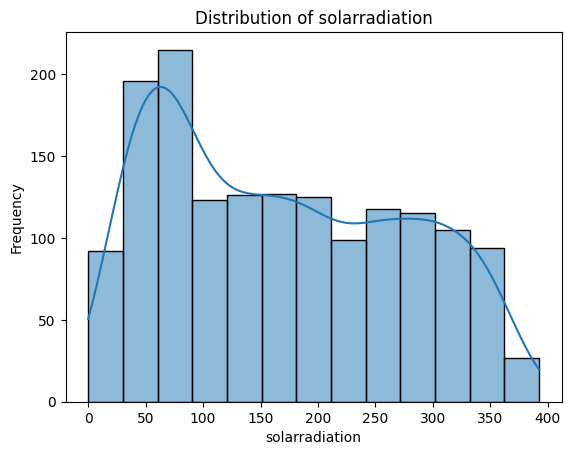

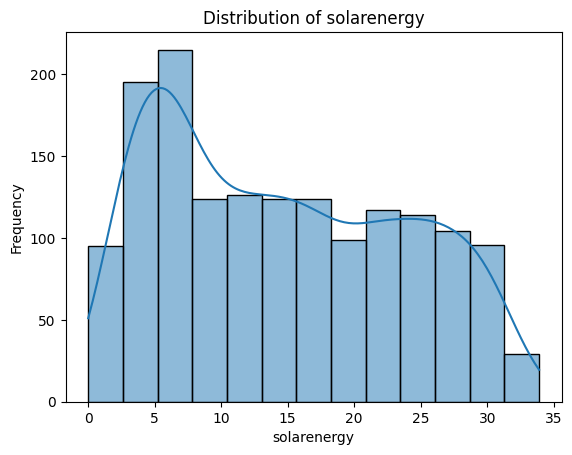

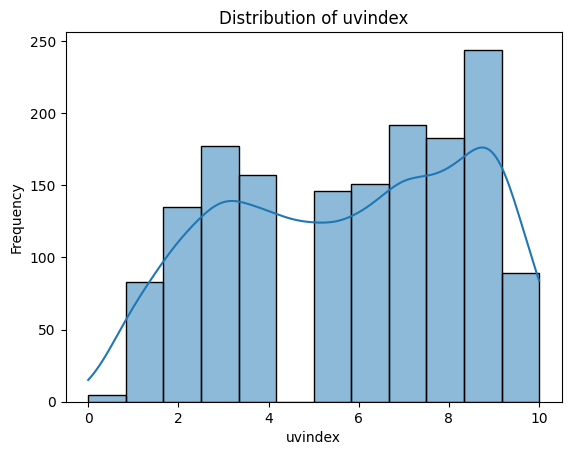

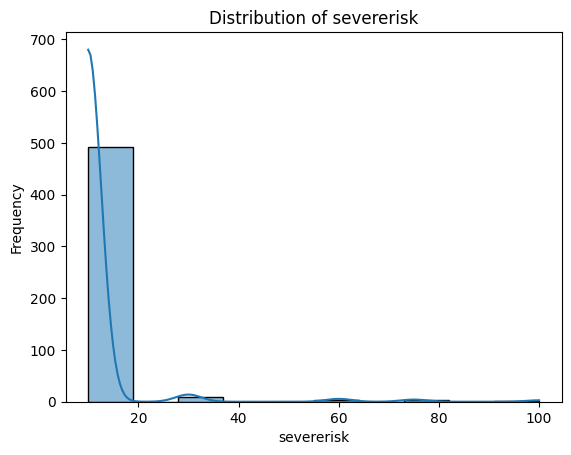

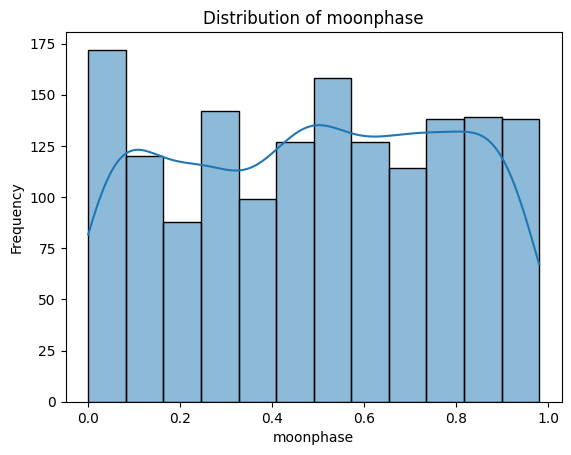

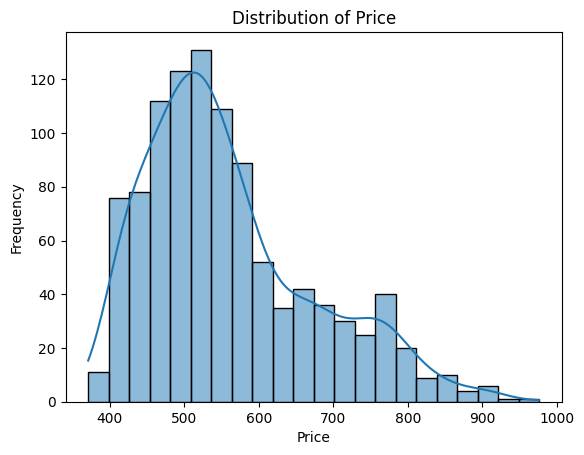

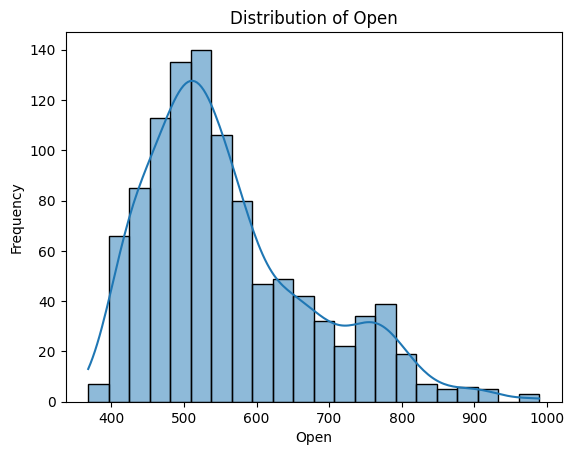

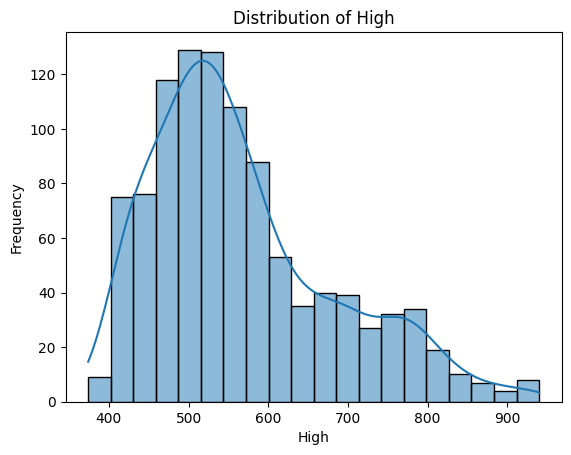

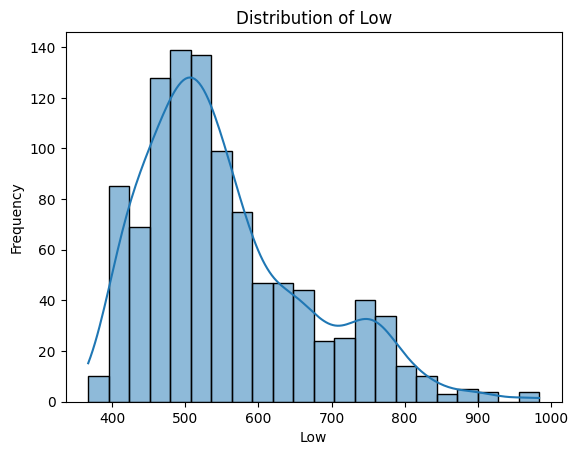

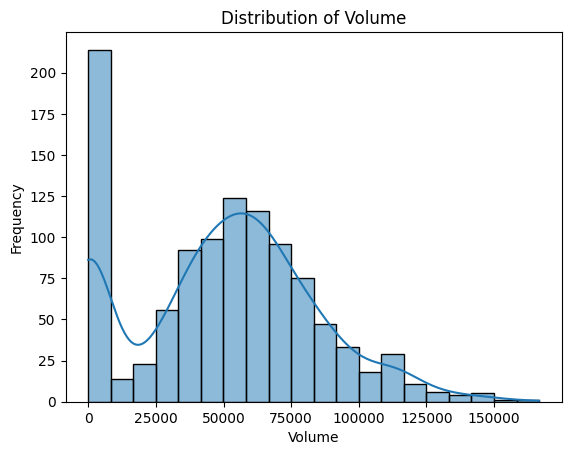

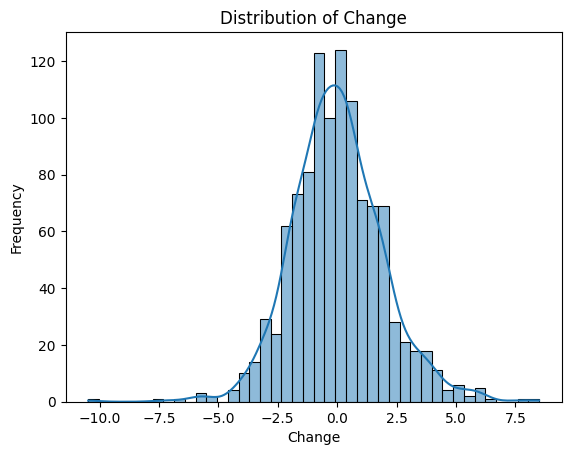

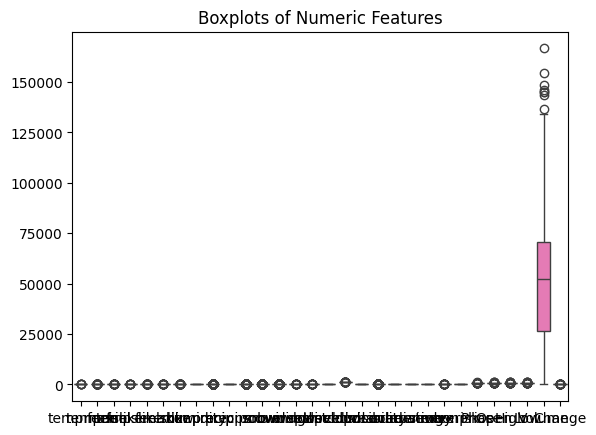

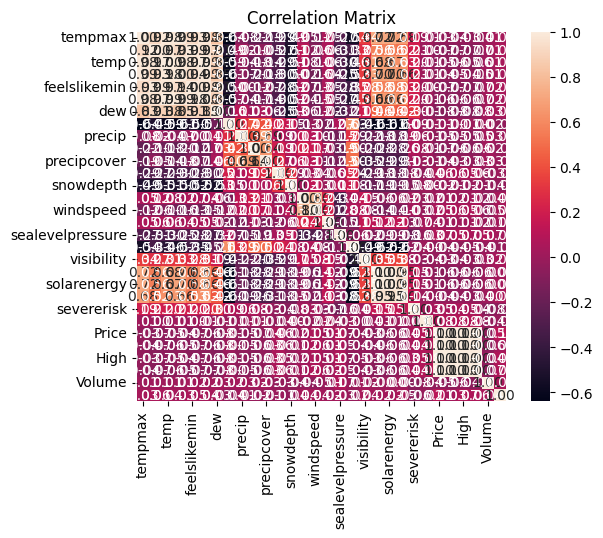

ValueError: Could not interpret value `Player` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [6]:
##Convert PySpark DataFrame to Pandas DataFrame for Data Visualization
pdf = merged_clean.sample(False, 0.1, seed=42).toPandas()
#Univariate histograms
for c in numeric_cols:
    sns.histplot(pdf[c].dropna(), kde=True)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

#Boxplots of numeric features
sns.boxplot(data=pdf[numeric_cols])
plt.title("Boxplots of Numeric Features")
plt.show()

#Correlation heatmap
corr = pdf[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

#Scatterplot (temp vs. Price)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pdf, x='temp', y='Price', hue='Player', legend=False, s=50)
plt.title('Scatter Plot of PER vs. WS')
plt.xlabel('Player Efficiency Rating (PER)')
plt.ylabel('Win Shares (WS)')
plt.show()

#Time‑series of Price
if "Date" in pdf.columns and "Price" in pdf.columns:
    pdf["Date"] = pd.to_datetime(pdf["Date"])
    pdf = pdf.sort_values("Date")

    # raw line plot
    sns.lineplot(x="Date", y="Price", data=pdf)
    plt.title("Wheat Price Over Time")
    plt.show()


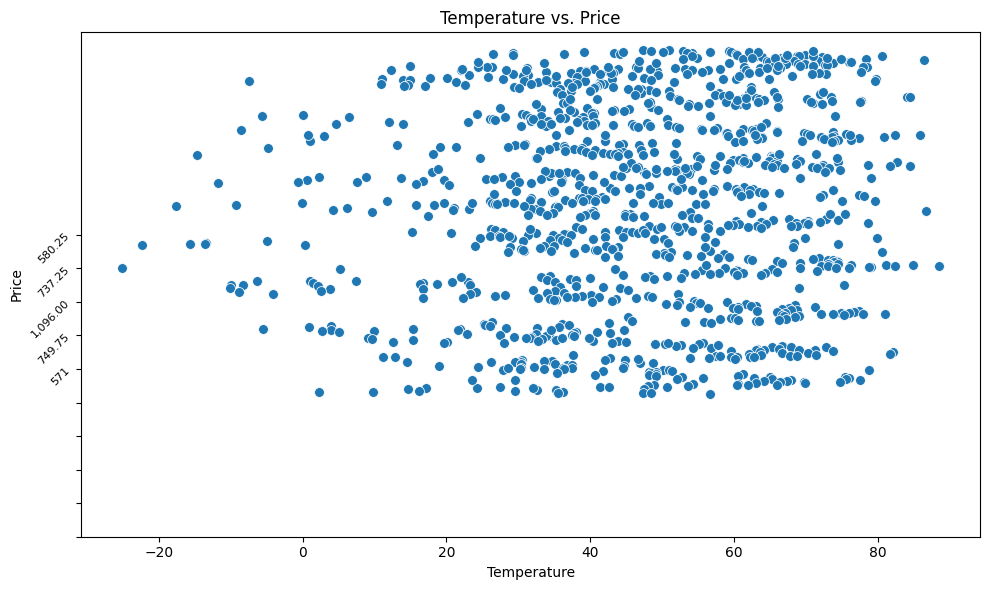

In [ ]:
# assume pdf['Price'] may have strings
prices = pd.to_numeric(pdf['Price'], errors='coerce').dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pdf, x='temp', y='Price', legend=False, s=50)
plt.title('Temperature vs. Price')
plt.xlabel('Temperature')
plt.ylabel('Price')

y_min, y_max = prices.min(), prices.max()
plt.yticks(np.linspace(y_min, y_max, 10), rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

Feature Engineering/Preprocessing Steps

In [ ]:
#one hot encode zip codes
#create lagged features?
#impute price nulls with most previous price data
#print/cast types, clean column names
#standard scale?
#Traintest split
#PCA potentially? 
        #probably not - we are using trees, and we need features to be interperetable.
#drop irrelavant rows
#encode percitiation types